# Datasets Combination

Merge all cleaned datasets into one

## A. Overview

List of datasets

- ACL_ICWSM_2018
- CrisisBench *(Combined)*
- CrisisLexT6
- CrisisLexT26
- CrisisMMD_V2
- CrisisNLP_R1
- Ecuador_Earthquake
- Eyewitness Messages
- HumAID
- ISCRAM2013
- SWDM2013

## B. Merge

In [78]:
from pathlib import Path
# import os
import pandas as pd

import configuration
from src import dataset_settings

# from dotenv import load_dotenv
# load_dotenv()

all_files = [f for f in Path('datasets').rglob('*.csv') if f != Path('datasets/CrisisBench.csv')]
print(f"Found {len(all_files)} CSV files in the datasets directory.")
for f in all_files:
    print(f" - {f}")

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

Found 10 CSV files in the datasets directory.
 - datasets/SWDM2013.csv
 - datasets/Ecuador_Earthquake_2016.csv
 - datasets/CrisisLexT6.csv
 - datasets/ISCRAM2013.csv
 - datasets/CrisisLexT26.csv
 - datasets/eyewitness_messages.csv
 - datasets/CrisisNLP.csv
 - datasets/ACL_ICWSM_2018.csv
 - datasets/HumAID.csv
 - datasets/CrisisMMD_v2.csv


### CrisisBench

The CrisisBench dataset combines
- CrisisLex
- CrisisNLP
- SWDM13
- ISCRAM13
- DRD
- DSM
- CrisisMMD
- AIDR

The author did some cleaning and mapping, so keep their works.

In [79]:
df_cb = pd.read_csv('datasets/CrisisBench.csv')


/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_61664/4161034626.py:1: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cb = pd.read_csv('datasets/CrisisBench.csv')


In [80]:
print(f"df_cb: {len(df_cb)} rows")
print(f"df: {len(df)} rows")

df_cb: 151999 rows
df: 225163 rows


In [81]:
df = df[~df['tweet_id'].isin(df_cb['tweet_id'])]
df = df[~df['tweet_text'].isin(df_cb['tweet_text'])]

df = pd.concat([df, df_cb], ignore_index=True)

df['tweet_id'] = df['tweet_id'].astype(str)

In [82]:
print(f"df: {len(df)} rows")

df: 257223 rows


# C. Clean

## C.1. Duplicated

In [83]:
df_dup_id = df[df.duplicated(subset=['tweet_id'], keep=False)]
print(f"Number of duplicate tweet_ids: {len(df_dup_id)}")

df_dup_text = df[df.duplicated(subset=['tweet_text'], keep=False)]
print(f"Number of duplicate tweet_texts: {len(df_dup_text)}")

Number of duplicate tweet_ids: 138
Number of duplicate tweet_texts: 192


In [84]:
set(df_dup_id['tweet_id']).issubset(set(df_dup_text['tweet_id']))

False

In [87]:
df = df.drop_duplicates(subset=['tweet_id']).drop_duplicates(subset=['tweet_text'])
print(f"df: {len(df)} rows")

df: 257098 rows


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257098 entries, 0 to 257222
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   relevant                     256690 non-null  float64
 1   tweet_text                   257097 non-null  object 
 2   tweet_id                     257098 non-null  object 
 3   humanitarian_label           205199 non-null  object 
 4   original_humanitarian_label  201025 non-null  object 
 5   event_type                   257098 non-null  object 
 6   dataset                      257098 non-null  object 
 7   year                         105102 non-null  float64
 8   event_name                   243297 non-null  object 
 9   meta                         104583 non-null  object 
 10  url                          4174 non-null    object 
 11  original_relevant_label      163835 non-null  object 
 12  source                       151996 non-null  object 
dtypes: f

In [89]:
df.head()

,relevant,tweet_text,tweet_id,humanitarian_label,original_humanitarian_label,event_type,dataset,year,event_name,meta,url,original_relevant_label,source
0,1.0,RT @MichaelHwrdSaul: Mayor Bloomberg calls it ...,999080191633762472432,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
1,1.0,"RT @xeni: Bloomberg ""our priority is protectin...",999176214043245279029,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
2,0.0,"I think she just signed ""Fuck Chris Christie!""...",999184446686026812868,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
3,1.0,We are now officially cut off from the rest of...,999418488332978841649,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
4,0.0,"RT @hum0rdenoche: El huracÃ­Ã§n ""Sandy"" debiÃ­...",999930148022756051001,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN


Datasets List

<Axes: xlabel='dataset'>

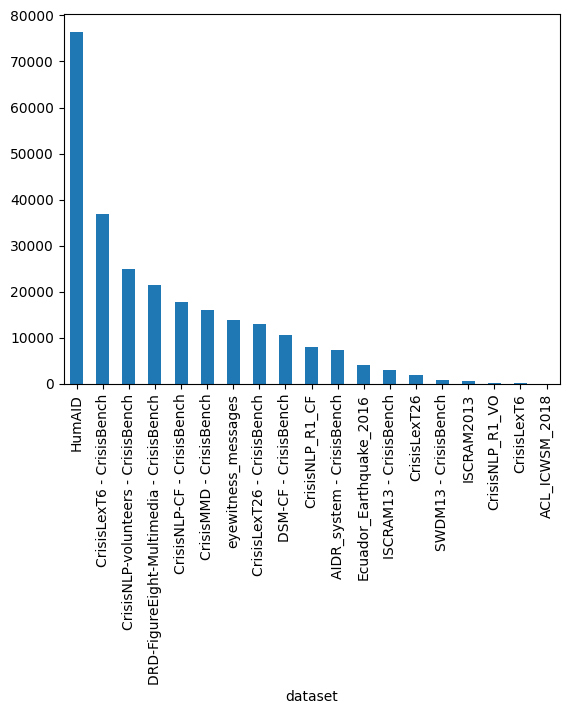

In [90]:
df['dataset'].value_counts().plot(kind='bar')

[nan 'Unknown' 'Information Source' 'injured_or_dead_people'
 'other_useful_information' 'sympathy_and_emotional_support'
 'infrastructure_and_utilities_damage'
 'donation_needs_or_offers_or_volunteering_services' 'caution_and_advice'
 'displaced_people_and_evacuations' 'missing_trapped_or_found_people'
 'not_related_or_irrelevant' 'Information source' 'Caution and advice'
 'Casualties and damage' 'Donations of money, goods or services'
 'rescue_volunteering_or_donation_effort' 'sympathy_and_support'
 'infrastructure_and_utility_damage' 'other_relevant_information'
 'not_humanitarian' 'requests_or_urgent_needs' 'missing_or_found_people'
 'requests_or_needs' 'affected_individual' 'donation_and_volunteering'
 'personal_update' 'missing_and_found_people' 'response_efforts'
 'displaced_and_evacuations' 'physical_landslide' 'disease_related']


<Axes: xlabel='humanitarian_label'>

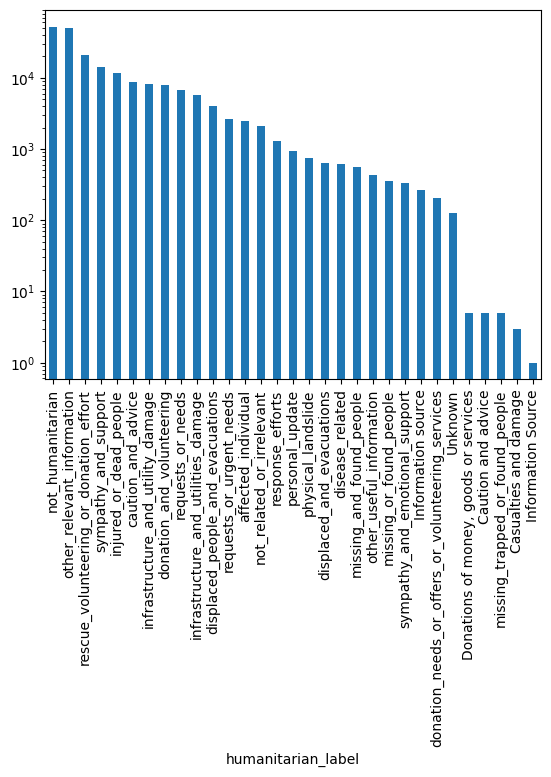

In [91]:
print(df['humanitarian_label'].unique())
df['humanitarian_label'].value_counts().plot(kind='bar', logy=True)

<Axes: xlabel='event_type'>

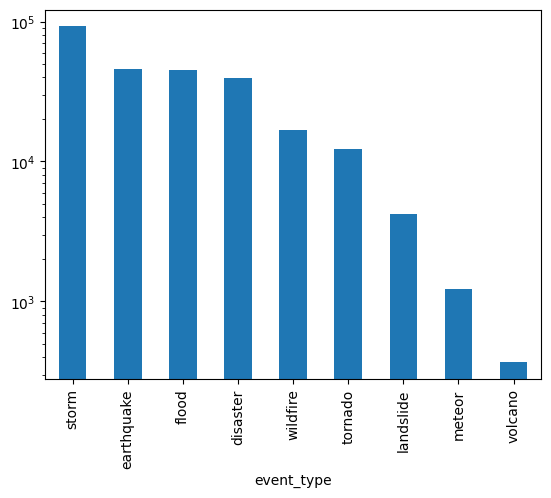

In [92]:
df['event_type'].value_counts().plot(kind='bar', logy=True)

Text(0.5, 1.0, 'Number of event_name entries for each event_type')

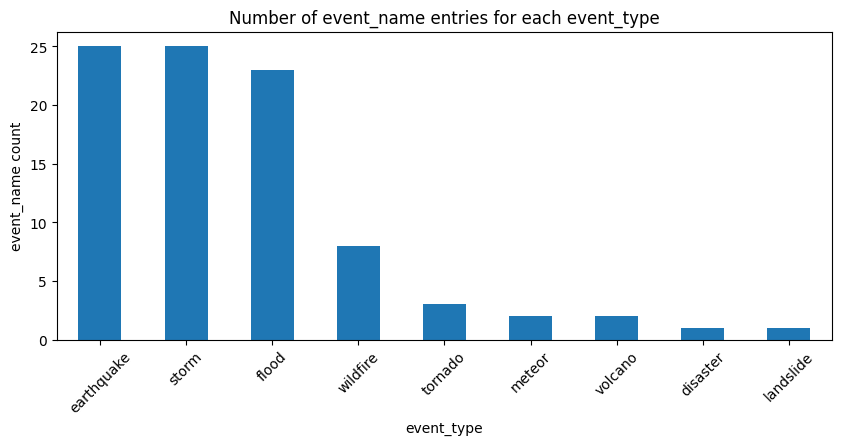

In [93]:
event_name_count_by_type = (
    df.groupby('event_type')['event_name']
      .nunique()
      .sort_values(ascending=False)
)

ax = event_name_count_by_type.plot(kind='bar', figsize=(10, 4), rot=45)
ax.set_xlabel('event_type')
ax.set_ylabel('event_name count')
ax.set_title('Number of event_name entries for each event_type')

In [99]:
event_name_count_by_type.head(10)

event_type
earthquake    25
storm         25
flood         23
wildfire       8
tornado        3
meteor         2
volcano        2
disaster       1
landslide      1
Name: event_name, dtype: int64

<Axes: xlabel='relevant'>

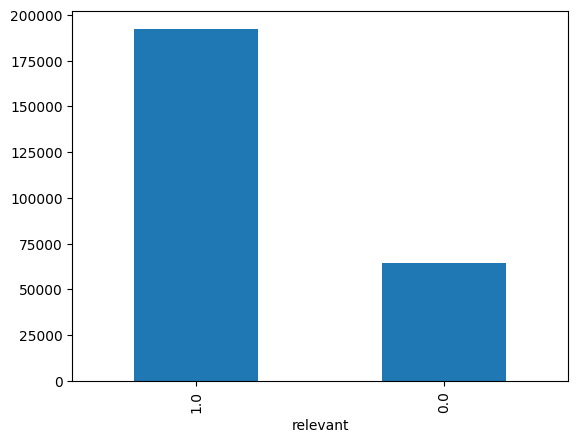

In [95]:
df['relevant'].value_counts().plot(kind='bar')

In [96]:
import csv

df.to_csv('data/unified_dataset.csv', index=False, quoting=csv.QUOTE_ALL)

In [97]:
df.head()

,relevant,tweet_text,tweet_id,humanitarian_label,original_humanitarian_label,event_type,dataset,year,event_name,meta,url,original_relevant_label,source
0,1.0,RT @MichaelHwrdSaul: Mayor Bloomberg calls it ...,999080191633762472432,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
1,1.0,"RT @xeni: Bloomberg ""our priority is protectin...",999176214043245279029,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
2,0.0,"I think she just signed ""Fuck Chris Christie!""...",999184446686026812868,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
3,1.0,We are now officially cut off from the rest of...,999418488332978841649,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
4,0.0,"RT @hum0rdenoche: El huracÃ­Ã§n ""Sandy"" debiÃ­...",999930148022756051001,NaN,NaN,storm,ISCRAM2013,2011.0,2011 Joplin tornado,NaN,NaN,NaN,NaN
